# Anexo — Formulación propia de la Torre de Hanoi

> Esto no es la entrega. La entrega es
> [`01_ejercicio_torre_de_hanoi.ipynb`](01_ejercicio_torre_de_hanoi.ipynb), que completa la
> plantilla de la cátedra con su biblioteca `aima_libs`.

Antes de arrancar con la plantilla armé el problema por mi cuenta, para entenderlo bien. Lo
dejo porque acá probé también profundidad, profundidad iterativa y búsqueda voraz, que en
el notebook de la entrega no están.

La heurística es la misma. Lo único que cambia es cómo represento el estado: acá uso una
tupla en vez de los objetos `StatesHanoi` de la cátedra.

Me guié por las diapositivas 63 a 69 del teórico: 5 discos, 3 varillas, costo 1 por
movimiento y un solo estado objetivo.

In [1]:
import heapq
import itertools
import time

import matplotlib.pyplot as plt

AZUL, NARANJA = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
})

N_DISCOS = 5
ORIGEN, AUXILIAR, DESTINO = 0, 1, 2

## Cómo planteé el problema

Represento el estado con una tupla de 5 posiciones, donde el índice es el disco (el 0 es el
más chico) y el valor es la varilla en la que está:

    estado[d] = varilla donde está el disco d

No necesito guardar el orden dentro de cada varilla, porque un disco nunca puede quedar
apoyado sobre uno más chico, así que el orden de cada pila ya queda determinado por los
tamaños. Por eso el espacio de estados da exactamente 3⁵ = 243, el mismo número que aparece
en la diapositiva 65.

El estado inicial es `(0, 0, 0, 0, 0)`, con todo en la varilla de origen, y el objetivo es
`(2, 2, 2, 2, 2)`. Cada movimiento válido cuesta 1, y busco la secuencia de menor costo.

In [2]:
ESTADO_INICIAL = (ORIGEN,) * N_DISCOS
ESTADO_OBJETIVO = (DESTINO,) * N_DISCOS


def discos_superiores(estado):
    """Devuelve {varilla: disco mas chico que hay en ella}, o sea el unico movible."""
    tope = {}
    for disco in range(len(estado)):          # de mas chico a mas grande
        varilla = estado[disco]
        if varilla not in tope:               # el primero que aparece es el mas chico
            tope[varilla] = disco
    return tope


def acciones(estado):
    """ACTIONS(s): movimientos validos como (disco, varilla_origen, varilla_destino)."""
    tope = discos_superiores(estado)
    validas = []
    for varilla, disco in tope.items():
        for destino in range(3):
            if destino == varilla:
                continue
            # vale si la varilla destino esta vacia o su disco superior es mas grande
            if destino not in tope or tope[destino] > disco:
                validas.append((disco, varilla, destino))
    return sorted(validas)


def resultado(estado, accion):
    """RESULT(s, a): estado que se obtiene al aplicar la accion."""
    disco, _, destino = accion
    nuevo = list(estado)
    nuevo[disco] = destino
    return tuple(nuevo)


COSTO_ACCION = 1   # ACTION-COST(s, a, s') = 1 para todo movimiento

print("Estado inicial :", ESTADO_INICIAL)
print("Estado objetivo:", ESTADO_OBJETIVO)
print("Acciones desde el inicial:", acciones(ESTADO_INICIAL))

Estado inicial : (0, 0, 0, 0, 0)
Estado objetivo: (2, 2, 2, 2, 2)
Acciones desde el inicial: [(0, 0, 1), (0, 0, 2)]


Desde el inicial salen solo dos movimientos, y los dos mueven el disco más chico. Tiene
sentido: con todos los discos apilados, lo único que se puede tocar es el de arriba.

Chequeo que el espacio de estados dé 243.

In [3]:
def estados_alcanzables(inicial):
    """Recorre el grafo de estados completo. Es una verificacion del modelo, no el
    algoritmo de la entrega."""
    vistos, pendientes = {inicial}, [inicial]
    while pendientes:
        estado = pendientes.pop()
        for acc in acciones(estado):
            siguiente = resultado(estado, acc)
            if siguiente not in vistos:
                vistos.add(siguiente)
                pendientes.append(siguiente)
    return vistos


alcanzables = estados_alcanzables(ESTADO_INICIAL)
print(f"Estados alcanzables: {len(alcanzables)}")
print(f"3^{N_DISCOS} = {3 ** N_DISCOS}")
print("Coincide con la diapositiva 65:", len(alcanzables) == 3 ** N_DISCOS)

Estados alcanzables: 243
3^5 = 243
Coincide con la diapositiva 65: True


## Las dos heurísticas

`h(n)` estima cuánto falta desde el nodo `n` hasta el objetivo. Para que A\* garantice el
óptimo no se tiene que pasar nunca del costo real.

La base cuenta cuántos discos no están todavía en la varilla destino. Es admisible, porque
cada uno de esos discos necesita al menos un movimiento, pero queda muy floja: como mucho
vale 5 cuando la solución cuesta 31. Subestima tanto que casi no orienta la búsqueda.

In [4]:
def h_discos_fuera(estado):
    """Heuristica base: cantidad de discos que todavia no estan en la varilla destino."""
    return sum(1 for varilla in estado if varilla != DESTINO)


print("h_discos_fuera(inicial)  =", h_discos_fuera(ESTADO_INICIAL))
print("h_discos_fuera(objetivo) =", h_discos_fuera(ESTADO_OBJETIVO))
print("Costo real de la solucion = 31 -> la heuristica subestima por 26")

h_discos_fuera(inicial)  = 5
h_discos_fuera(objetivo) = 0
Costo real de la solucion = 31 -> la heuristica subestima por 26


La otra es la que armé yo, y es la que uso en la entrega. La idea es razonar sobre el disco
más grande.

Llamo `d(k, t)` al mínimo de movimientos para llevar los discos `0..k` a la varilla `t`. Si
el disco `k` ya está en `t` no conviene moverlo, así que queda `d(k, t) = d(k-1, t)`. Si
está en otra varilla `p`, para poder moverlo los discos más chicos tienen que estar todos
en la tercera varilla `o = 3 - p - t`, y ahí hacen falta tres cosas obligatorias: llevarlos
a `o`, mover el disco `k`, y después pasar la torre entera de `o` a `t`, que cuesta
`2^k - 1`. Sumando queda `d(k, t) = d(k-1, o) + 2^k`.

Como las tres cosas son obligatorias y no se pisan, la suma da el mínimo y no una cota
floja. Al desplegarlo no hace falta recursión: alcanza con recorrer los discos de mayor a
menor sumando `2^k` cada vez que el disco `k` no está donde va.

In [5]:
def h_distancia_exacta(estado):
    """Heuristica propia: minimo exacto de movimientos hasta el objetivo.

    Recorre los discos del mas grande al mas chico. Cada vez que un disco no esta en la
    varilla donde deberia, ese disco tendra que moverse y ademas obliga a todos los mas
    chicos a pasar por la tercera varilla, lo que cuesta 2**disco en total.
    """
    total = 0
    objetivo = DESTINO
    for disco in range(len(estado) - 1, -1, -1):       # del mas grande al mas chico
        if estado[disco] != objetivo:
            total += 2 ** disco                        # 1 + (2**disco - 1)
            objetivo = 3 - estado[disco] - objetivo    # la tercera varilla
    return total


print("h_distancia_exacta(inicial)  =", h_distancia_exacta(ESTADO_INICIAL))
print("2^5 - 1                      =", 2 ** N_DISCOS - 1)
print("h_distancia_exacta(objetivo) =", h_distancia_exacta(ESTADO_OBJETIVO))

h_distancia_exacta(inicial)  = 31
2^5 - 1                      = 31
h_distancia_exacta(objetivo) = 0


En el estado inicial da 31, que es justo lo que cuesta la solución óptima. Ya ahí se ve que
no es una cota floja sino el valor exacto.

## Chequeo que las heurísticas sean válidas

A\* necesita que sean admisibles y consistentes. Lo verifico sobre los 243 estados en vez
de sobre un par de ejemplos.

Para tener la distancia real de cada estado uso un costo uniforme hacia atrás desde el
objetivo, que se puede porque los movimientos son reversibles. Es solo para verificar, el
algoritmo que resuelve es A\*.

In [6]:
def distancias_reales_al_objetivo():
    """Costo uniforme hacia atras desde el objetivo: da la distancia real de cada estado.
    Se usa solo para verificar las heuristicas."""
    contador = itertools.count()
    frontera = [(0, next(contador), ESTADO_OBJETIVO)]
    distancia = {ESTADO_OBJETIVO: 0}
    while frontera:
        costo, _, estado = heapq.heappop(frontera)
        if costo > distancia[estado]:
            continue
        for acc in acciones(estado):                 # los movimientos son reversibles
            vecino = resultado(estado, acc)
            if costo + COSTO_ACCION < distancia.get(vecino, float("inf")):
                distancia[vecino] = costo + COSTO_ACCION
                heapq.heappush(frontera, (distancia[vecino], next(contador), vecino))
    return distancia


real = distancias_reales_al_objetivo()
print(f"Estados etiquetados: {len(real)}")
print(f"Distancia real del inicial al objetivo: {real[ESTADO_INICIAL]}")

Estados etiquetados: 243
Distancia real del inicial al objetivo: 31


In [7]:
def revisar(h, nombre):
    sobreestima = [e for e in real if h(e) > real[e]]
    exacta = sum(1 for e in real if h(e) == real[e])
    inconsistente = [
        (e, acc) for e in real for acc in acciones(e)
        if h(e) > COSTO_ACCION + h(resultado(e, acc))
    ]
    print(nombre)
    print(f"   admisible (nunca sobreestima)   : {not sobreestima}"
          f"   [{len(sobreestima)} estados la violan]")
    print(f"   consistente (h(n) <= c + h(n')) : {not inconsistente}"
          f"   [{len(inconsistente)} transiciones la violan]")
    print(f"   coincide con la distancia real  : {exacta} de {len(real)} estados")
    print()


revisar(h_discos_fuera, "h_discos_fuera (base)")
revisar(h_distancia_exacta, "h_distancia_exacta (propia)")

h_discos_fuera (base)
   admisible (nunca sobreestima)   : True   [0 estados la violan]
   consistente (h(n) <= c + h(n')) : True   [0 transiciones la violan]
   coincide con la distancia real  : 5 de 243 estados

h_distancia_exacta (propia)
   admisible (nunca sobreestima)   : True   [0 estados la violan]
   consistente (h(n) <= c + h(n')) : True   [0 transiciones la violan]
   coincide con la distancia real  : 243 de 243 estados



Las dos pasan, así que A\* encuentra el óptimo con cualquiera. La diferencia es cuánto
informan: la base coincide con la distancia real en muy pocos estados, y la mía coincide en
los 243. No es una estimación, es la distancia exacta.

Eso tiene una consecuencia concreta. Si `h` es la distancia real, `f(n) = g(n) + h(n)` es
el costo del mejor camino que pasa por `n`, así que todos los nodos del camino óptimo
comparten el mismo `f` y cualquier nodo fuera de ese camino tiene uno más grande. Por eso
A\* no se desvía.

## A\*

Ordena la frontera por `f(n) = g(n) + h(n)`, con `g(n)` el costo acumulado y `h(n)` lo que
falta.

In [8]:
def a_estrella(h, inicial=ESTADO_INICIAL, objetivo=ESTADO_OBJETIVO):
    """Busqueda A*. Devuelve el camino y las metricas de la busqueda."""
    contador = itertools.count()                     # desempata sin comparar tuplas
    frontera = [(h(inicial), next(contador), inicial)]
    padre = {inicial: None}
    g = {inicial: 0}
    cerrados = set()
    expandidos, generados = 0, 1
    frontera_maxima = 1

    while frontera:
        frontera_maxima = max(frontera_maxima, len(frontera))
        _, _, estado = heapq.heappop(frontera)

        if estado in cerrados:                        # entrada vieja de la cola
            continue
        cerrados.add(estado)
        expandidos += 1

        if estado == objetivo:
            camino = []
            while estado is not None:
                camino.append(estado)
                estado = padre[estado]
            return {"camino": camino[::-1], "costo": g[objetivo],
                    "expandidos": expandidos, "generados": generados,
                    "frontera_maxima": frontera_maxima}

        for acc in acciones(estado):
            vecino = resultado(estado, acc)
            nuevo_g = g[estado] + COSTO_ACCION
            if nuevo_g < g.get(vecino, float("inf")):
                g[vecino] = nuevo_g
                padre[vecino] = estado
                generados += 1
                heapq.heappush(frontera, (nuevo_g + h(vecino), next(contador), vecino))

    return None

In [9]:
inicio = time.perf_counter()
solucion = a_estrella(h_distancia_exacta)
tardanza = time.perf_counter() - inicio

print(f"Costo de la solucion : {solucion['costo']} movimientos")
print(f"Optimo teorico       : {2 ** N_DISCOS - 1} movimientos")
print(f"Nodos expandidos     : {solucion['expandidos']}")
print(f"Nodos generados      : {solucion['generados']}")
print(f"Frontera maxima      : {solucion['frontera_maxima']}")
print(f"Tiempo               : {tardanza * 1000:.2f} ms")

Costo de la solucion : 31 movimientos
Optimo teorico       : 31 movimientos
Nodos expandidos     : 32
Nodos generados      : 48
Frontera maxima      : 17
Tiempo               : 0.17 ms


Que el costo dé 31 no alcanza, hay que ver que la secuencia se pueda jugar. Reviso
movimiento por movimiento que cada paso sea una acción legal, que se mueva un solo disco por
vez y que termine en el objetivo.

In [10]:
def validar(camino):
    assert camino[0] == ESTADO_INICIAL, "no arranca en el estado inicial"
    assert camino[-1] == ESTADO_OBJETIVO, "no termina en el estado objetivo"
    for anterior, siguiente in zip(camino, camino[1:]):
        legales = [resultado(anterior, a) for a in acciones(anterior)]
        assert siguiente in legales, f"movimiento ilegal: {anterior} -> {siguiente}"
        cambiados = [d for d in range(N_DISCOS) if anterior[d] != siguiente[d]]
        assert len(cambiados) == 1, "se movio mas de un disco a la vez"
    return True


print("Secuencia valida:", validar(solucion["camino"]))
print(f"Movimientos: {len(solucion['camino']) - 1}")

Secuencia valida: True
Movimientos: 31


In [11]:
def describir(camino):
    nombres = {0: "origen", 1: "auxiliar", 2: "destino"}
    for i, (a, b) in enumerate(zip(camino, camino[1:]), start=1):
        disco = next(d for d in range(N_DISCOS) if a[d] != b[d])
        print(f"{i:>3}. disco {disco + 1}: {nombres[a[disco]]:>8} -> {nombres[b[disco]]}")


describir(solucion["camino"])

  1. disco 1:   origen -> destino
  2. disco 2:   origen -> auxiliar
  3. disco 1:  destino -> auxiliar
  4. disco 3:   origen -> destino
  5. disco 1: auxiliar -> origen
  6. disco 2: auxiliar -> destino
  7. disco 1:   origen -> destino
  8. disco 4:   origen -> auxiliar
  9. disco 1:  destino -> auxiliar
 10. disco 2:  destino -> origen
 11. disco 1: auxiliar -> origen
 12. disco 3:  destino -> auxiliar
 13. disco 1:   origen -> destino
 14. disco 2:   origen -> auxiliar
 15. disco 1:  destino -> auxiliar
 16. disco 5:   origen -> destino
 17. disco 1: auxiliar -> origen
 18. disco 2: auxiliar -> destino
 19. disco 1:   origen -> destino
 20. disco 3: auxiliar -> origen
 21. disco 1:  destino -> auxiliar
 22. disco 2:  destino -> origen
 23. disco 1: auxiliar -> origen
 24. disco 4: auxiliar -> destino
 25. disco 1:   origen -> destino
 26. disco 2:   origen -> auxiliar
 27. disco 1:  destino -> auxiliar
 28. disco 3:   origen -> destino
 29. disco 1: auxiliar -> origen
 30. disco 2

In [12]:
def dibujar(estado):
    """Dibuja las tres varillas en texto."""
    pilas = {v: [] for v in range(3)}
    for disco in range(N_DISCOS - 1, -1, -1):        # de grande a chico: la base primero
        pilas[estado[disco]].append(disco + 1)
    ancho = 2 * N_DISCOS + 1
    filas = []
    for nivel in range(N_DISCOS):
        fila = []
        for v in range(3):
            faltan = N_DISCOS - len(pilas[v])
            if nivel < faltan:
                fila.append("|".center(ancho))
            else:
                disco = pilas[v][nivel - faltan]
                fila.append(("#" * (2 * disco + 1)).center(ancho))
        filas.append("  ".join(fila))
    filas.append("  ".join("=" * ancho for _ in range(3)))
    filas.append("  ".join(n.center(ancho) for n in ("origen", "auxiliar", "destino")))
    return "\n".join(filas)


camino = solucion["camino"]
for etiqueta, estado in [("ESTADO INICIAL", camino[0]),
                         ("PASO 15", camino[15]),
                         ("ESTADO FINAL", camino[-1])]:
    print(etiqueta)
    print(dibujar(estado))
    print()

ESTADO INICIAL
###########       |            |     
 #########        |            |     
  #######         |            |     
   #####          |            |     
    ###           |            |     
===========  ===========  ===========
   origen      auxiliar     destino  

PASO 15
     |            |            |     
     |        #########        |     
     |         #######         |     
     |          #####          |     
###########      ###           |     
===========  ===========  ===========
   origen      auxiliar     destino  

ESTADO FINAL
     |            |       ###########
     |            |        ######### 
     |            |         #######  
     |            |          #####   
     |            |           ###    
===========  ===========  ===========
   origen      auxiliar     destino  



## Comparación con los otros algoritmos

Implementé los demás algoritmos que menciona la consigna para ver cuántos nodos necesita
cada uno. Ninguno es BFS.

In [13]:
def profundidad(inicial=ESTADO_INICIAL, objetivo=ESTADO_OBJETIVO):
    """Busqueda primero en profundidad, con control de estados ya vistos."""
    pila = [inicial]
    padre = {inicial: None}
    expandidos, generados = 0, 1
    frontera_maxima = 1
    while pila:
        frontera_maxima = max(frontera_maxima, len(pila))
        estado = pila.pop()
        expandidos += 1
        if estado == objetivo:
            ruta = []
            while estado is not None:
                ruta.append(estado)
                estado = padre[estado]
            return {"camino": ruta[::-1], "costo": len(ruta) - 1,
                    "expandidos": expandidos, "generados": generados,
                    "frontera_maxima": frontera_maxima}
        for acc in acciones(estado):
            vecino = resultado(estado, acc)
            if vecino not in padre:
                padre[vecino] = estado
                generados += 1
                pila.append(vecino)
    return None


def costo_uniforme(inicial=ESTADO_INICIAL, objetivo=ESTADO_OBJETIVO):
    """Busqueda de costo uniforme: es A* con h = 0."""
    return a_estrella(lambda estado: 0, inicial, objetivo)


def voraz(h, inicial=ESTADO_INICIAL, objetivo=ESTADO_OBJETIVO):
    """Busqueda voraz: ordena la frontera solo por h(n), sin tener en cuenta g(n)."""
    contador = itertools.count()
    frontera = [(h(inicial), next(contador), inicial)]
    padre = {inicial: None}
    cerrados = set()
    expandidos, generados = 0, 1
    frontera_maxima = 1
    while frontera:
        frontera_maxima = max(frontera_maxima, len(frontera))
        _, _, estado = heapq.heappop(frontera)
        if estado in cerrados:
            continue
        cerrados.add(estado)
        expandidos += 1
        if estado == objetivo:
            ruta = []
            while estado is not None:
                ruta.append(estado)
                estado = padre[estado]
            return {"camino": ruta[::-1], "costo": len(ruta) - 1,
                    "expandidos": expandidos, "generados": generados,
                    "frontera_maxima": frontera_maxima}
        for acc in acciones(estado):
            vecino = resultado(estado, acc)
            if vecino not in cerrados and vecino not in padre:
                padre[vecino] = estado
                generados += 1
                heapq.heappush(frontera, (h(vecino), next(contador), vecino))
    return None

In [14]:
pruebas = [
    ("Profundidad (DFS)", profundidad),
    ("Costo uniforme", costo_uniforme),
    ("Voraz + h base", lambda: voraz(h_discos_fuera)),
    ("Voraz + h propia", lambda: voraz(h_distancia_exacta)),
    ("A* + h base", lambda: a_estrella(h_discos_fuera)),
    ("A* + h propia", lambda: a_estrella(h_distancia_exacta)),
]

resultados = []
for nombre, fn in pruebas:
    t = time.perf_counter()
    r = fn()
    r["tiempo_ms"] = (time.perf_counter() - t) * 1000
    r["nombre"] = nombre
    resultados.append(r)

print(f"{'algoritmo':<20}{'movs':>6}{'optima':>9}{'expandidos':>12}"
      f"{'generados':>11}{'frontera':>10}{'ms':>8}")
print("-" * 76)
for r in resultados:
    print(f"{r['nombre']:<20}{r['costo']:>6}"
          f"{('si' if r['costo'] == 31 else 'NO'):>9}"
          f"{r['expandidos']:>12}{r['generados']:>11}"
          f"{r['frontera_maxima']:>10}{r['tiempo_ms']:>8.2f}")

algoritmo             movs   optima  expandidos  generados  frontera      ms
----------------------------------------------------------------------------
Profundidad (DFS)       81       NO          82        123        42    0.16
Costo uniforme          31       si         233        243        32    0.56
Voraz + h base          35       NO         168        181        14    0.40
Voraz + h propia        31       si          32         48        17    0.08
A* + h base             31       si         178        193        16    0.48
A* + h propia           31       si          32         48        17    0.09


Profundidad no sirve acá: devuelve 81 movimientos, casi el triple del óptimo. Es lo que
pasa cuando no mirás el costo, agarra una rama y se queda con la primera salida que
encuentra.

La heurística base expande 178 nodos, apenas mejor que los 233 del costo uniforme. Y la
propia expande 32, que son los 31 del camino más el objetivo.

La voraz con la heurística propia también llega a 31, pero eso es porque la heurística es
exacta. La voraz ignora `g(n)`, así que en general no garantiza el óptimo, y se nota con la
heurística base: devuelve 35 movimientos.

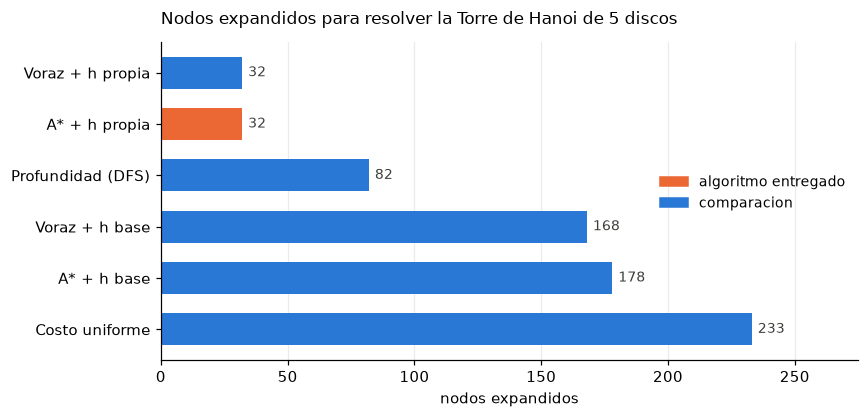

In [15]:
orden = sorted(resultados, key=lambda r: r["expandidos"])
etiquetas = [r["nombre"] for r in orden]
valores = [r["expandidos"] for r in orden]
colores = [NARANJA if r["nombre"] == "A* + h propia" else AZUL for r in orden]

fig, ax = plt.subplots(figsize=(8, 3.9))
barras = ax.barh(etiquetas, valores, color=colores, height=0.62)
ax.bar_label(barras, padding=4, fontsize=9, color="#3d3d3a")
ax.set_xlabel("nodos expandidos")
ax.set_xlim(0, max(valores) * 1.18)
ax.grid(axis="y", visible=False)
ax.invert_yaxis()

manijas = [plt.Rectangle((0, 0), 1, 1, color=NARANJA),
           plt.Rectangle((0, 0), 1, 1, color=AZUL)]
ax.legend(manijas, ["algoritmo entregado", "comparacion"],
          frameon=False, fontsize=9, loc="upper right", bbox_to_anchor=(1.0, 0.62))

ax.set_title("Nodos expandidos para resolver la Torre de Hanoi de 5 discos",
             fontsize=11, loc="left", pad=12)
plt.tight_layout()
plt.show()

## Profundidad iterativa

La consigna también menciona profundidad limitada con profundidad iterativa. La dejé
aparte porque el costo se dispara: repite el recorrido desde cero en cada límite y no puede
guardar todos los estados visitados, ya que su gracia es usar poca memoria.

La celda de abajo tarda alrededor de un minuto, casi todo en el caso de 5 discos.

In [16]:
def construir(n_discos):
    """Devuelve las funciones del problema para n discos, para ver como escala."""
    inicial, objetivo = (ORIGEN,) * n_discos, (DESTINO,) * n_discos

    def acc(estado):
        tope = {}
        for d in range(n_discos):
            if estado[d] not in tope:
                tope[estado[d]] = d
        return sorted((d, v, x) for v, d in tope.items() for x in range(3)
                      if x != v and (x not in tope or tope[x] > d))

    def res(estado, a):
        nuevo = list(estado)
        nuevo[a[0]] = a[2]
        return tuple(nuevo)

    def h(estado):
        total, obj = 0, DESTINO
        for d in range(n_discos - 1, -1, -1):
            if estado[d] != obj:
                total += 2 ** d
                obj = 3 - estado[d] - obj
        return total

    return inicial, objetivo, acc, res, h


def profundidad_iterativa(n_discos, limite_maximo=64):
    """Profundidad limitada, aumentando el limite hasta encontrar la solucion."""
    inicial, objetivo, acc, res, _ = construir(n_discos)

    def limitada(estado, limite, en_camino, visitas):
        visitas[0] += 1
        if estado == objetivo:
            return True
        if limite == 0:
            return False
        for a in acc(estado):
            vecino = res(estado, a)
            if vecino in en_camino:          # evita ciclos dentro del camino actual
                continue
            en_camino.add(vecino)
            if limitada(vecino, limite - 1, en_camino, visitas):
                return True
            en_camino.discard(vecino)
        return False

    for limite in range(limite_maximo + 1):
        visitas = [0]
        if limitada(inicial, limite, {inicial}, visitas):
            return limite, visitas[0]
    return None, 0


def astar_n(n_discos):
    """A* con la heuristica propia, para n discos."""
    inicial, objetivo, acc, res, h = construir(n_discos)
    contador = itertools.count()
    frontera = [(h(inicial), next(contador), inicial)]
    g = {inicial: 0}
    cerrados = set()
    expandidos = 0
    while frontera:
        _, _, estado = heapq.heappop(frontera)
        if estado in cerrados:
            continue
        cerrados.add(estado)
        expandidos += 1
        if estado == objetivo:
            return g[estado], expandidos
        for a in acc(estado):
            vecino = res(estado, a)
            nuevo = g[estado] + 1
            if nuevo < g.get(vecino, float("inf")):
                g[vecino] = nuevo
                heapq.heappush(frontera, (nuevo + h(vecino), next(contador), vecino))
    return None, expandidos

In [17]:
print(f"{'discos':>7}{'optimo':>8}{'IDDFS nodos':>15}{'IDDFS s':>10}"
      f"{'A* nodos':>11}{'A* s':>9}")
print("-" * 60)
for n in (3, 4, 5):
    t = time.perf_counter()
    _, nodos_id = profundidad_iterativa(n)
    t_id = time.perf_counter() - t

    t = time.perf_counter()
    costo, nodos_a = astar_n(n)
    t_a = time.perf_counter() - t

    print(f"{n:>7}{costo:>8}{nodos_id:>15,}{t_id:>10.2f}{nodos_a:>11}{t_a:>9.4f}")

 discos  optimo    IDDFS nodos   IDDFS s   A* nodos     A* s
------------------------------------------------------------
      3       7            133      0.00          8   0.0000
      4      15          3,610      0.02         16   0.0001


      5      31     22,624,914     73.97         32   0.0001


El salto de 4 a 5 discos multiplica por más de 6000 los nodos que visita la profundidad
iterativa, mientras que A\* pasa de 16 a 32.

Con esta heurística A\* expande siempre `2^n` nodos exactos, que son los `2^n - 1` del
camino óptimo más el objetivo. Es el mínimo que puede hacer cualquier algoritmo que tenga
que recorrer ese camino.

Resumiendo lo que salió de acá: la solución óptima son 31 movimientos, la heurística propia
quedó verificada sobre los 243 estados y expande 32 nodos contra 178 de la base y 233 del
costo uniforme. Y para ver lo que se paga por no usar heurística, profundidad devuelve 81
movimientos y profundidad iterativa necesita 22 millones de visitas para llegar a la misma
respuesta.